# StockWatch — ML Stockout Prediction Notebook
This notebook loads the generated CSV dataset (`synthetic_sales_data.csv`), performs feature engineering, trains a Linear Regression model, evaluates metrics (MAE, RMSE, R²), and exports `model.joblib`.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# 1. Load Dataset from CSV File
df = pd.read_csv('synthetic_sales_data.csv')
print(f"Loaded dataset with {len(df)} rows")
df.head()

Loaded dataset with 900 rows


,product_id,sale_date,quantity_sold,is_promo
0,1,2026-04-02,14,0
1,1,2026-04-03,46,1
2,1,2026-04-04,22,0
3,1,2026-04-05,24,0
4,1,2026-04-06,13,0


In [2]:
# 2. Feature Engineering
df['sale_date'] = pd.to_datetime(df['sale_date'])
df = df.sort_values(['product_id', 'sale_date']).reset_index(drop=True)

df['day_of_week'] = df['sale_date'].dt.dayofweek
min_date = df['sale_date'].min()
df['day_index'] = (df['sale_date'] - min_date).dt.days

# Per-product rolling features
df['rolling_7'] = df.groupby('product_id')['quantity_sold'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['rolling_14'] = df.groupby('product_id')['quantity_sold'].transform(lambda x: x.rolling(window=14, min_periods=1).mean())

df.dropna(inplace=True)
df[['product_id', 'sale_date', 'quantity_sold', 'day_of_week', 'day_index', 'rolling_7', 'rolling_14']].tail(10)

,product_id,sale_date,quantity_sold,day_of_week,day_index,rolling_7,rolling_14
890,5,2026-09-19,67,5,170,53.142857,58.142857
891,5,2026-09-20,67,6,171,53.285714,58.357143
892,5,2026-09-21,44,0,172,53.142857,58.571429
893,5,2026-09-22,44,1,173,53.285714,58.642857
894,5,2026-09-23,45,2,174,53.857143,58.642857
895,5,2026-09-24,44,3,175,54.000000,58.857143
896,5,2026-09-25,66,4,176,53.857143,53.428571
897,5,2026-09-26,67,5,177,53.857143,53.500000
898,5,2026-09-27,69,6,178,54.142857,53.714286
899,5,2026-09-28,42,0,179,53.857143,53.500000


In [3]:
# 3. Train-Test Split (Time-based split: last 30 days per product for testing)
features = ['day_of_week', 'day_index', 'rolling_7', 'rolling_14']
max_day = df['day_index'].max()
split_day = max_day - 30

train_df = df[df['day_index'] <= split_day]
test_df = df[df['day_index'] > split_day]

X_train, y_train = train_df[features], train_df['quantity_sold']
X_test, y_test = test_df[features], test_df['quantity_sold']

print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Training rows: 750, Testing rows: 150


In [4]:
# 4. Model Training & Evaluation
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Performance:")
print(f" - MAE : {mae:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - R²  : {r2:.4f}")

Linear Regression Performance:
 - MAE : 4.7954
 - RMSE: 8.8912
 - R²  : 0.7619


In [5]:
# 5. Save Model Artifact
joblib.dump(model, 'model.joblib')
print("Trained model saved to model.joblib")

Trained model saved to model.joblib


In [6]:
# 6. Predict Stockout Example for Product ID 1 with 100 Units Available
prod1_last = df[df['product_id'] == 1].iloc[-1]
current_inventory = 100.0

future_rows = []
last_day_index = prod1_last['day_index']
last_r7 = prod1_last['rolling_7']
last_r14 = prod1_last['rolling_14']
today = datetime.now().date()

for i in range(1, 8):
    f_date = today + timedelta(days=i)
    future_rows.append({
        'day_of_week': f_date.weekday(),
        'day_index': last_day_index + i,
        'rolling_7': last_r7,
        'rolling_14': last_r14
    })

X_future = pd.DataFrame(future_rows)
future_preds = model.predict(X_future)
avg_daily_demand = max(0.1, float(np.mean(future_preds)))
days_until_stockout = int(current_inventory / avg_daily_demand)
stockout_date = today + timedelta(days=days_until_stockout)

print(f"Product 1 Current Stock: {current_inventory}")
print(f"Predicted Daily Demand: {avg_daily_demand:.2f} units/day")
print(f"Days Until Stockout: {days_until_stockout} days (Date: {stockout_date})")

Product 1 Current Stock: 100.0
Predicted Daily Demand: 33.72 units/day
Days Until Stockout: 2 days (Date: 2026-10-01)


## 7. Model Visualization
Visualizing actual daily sales against the fitted linear regression model and the 7-day demand forecast.

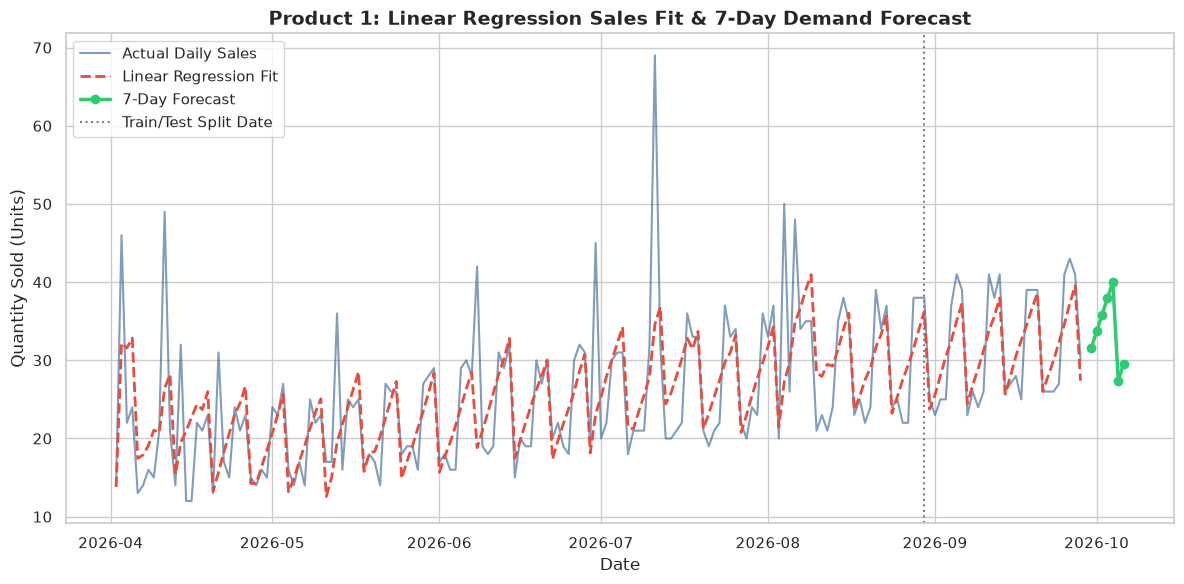

In [7]:
# 7. Visualization: Historical Sales vs. Fitted Linear Regression & 7-Day Forecast
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Filter for Product 1
prod1_df = df[df['product_id'] == 1].copy()
prod1_train = train_df[train_df['product_id'] == 1]
prod1_test = test_df[test_df['product_id'] == 1]

# Predictions on historical data for Product 1
prod1_fitted = model.predict(prod1_df[features])

# Plot actual sales
plt.plot(prod1_df['sale_date'], prod1_df['quantity_sold'], label='Actual Daily Sales', color='#2b5c8f', alpha=0.6, linewidth=1.5)

# Plot Linear Regression fitted trend
plt.plot(prod1_df['sale_date'], prod1_fitted, label='Linear Regression Fit', color='#e74c3c', linestyle='--', linewidth=2)

# Plot 7-day future predictions
future_dates = [today + timedelta(days=i) for i in range(1, 8)]
plt.plot(future_dates, future_preds, label='7-Day Forecast', color='#2ecc71', marker='o', linewidth=2.5)

plt.title('Product 1: Linear Regression Sales Fit & 7-Day Demand Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity Sold (Units)', fontsize=12)
plt.axvline(x=prod1_test['sale_date'].min(), color='gray', linestyle=':', label='Train/Test Split Date')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Multi-Algorithm Visualization Comparison
Comparing **Linear Regression** against **Decision Tree Regressor** and **Random Forest Regressor** on historical fit and 7-day demand forecast.

Model Performance Comparison (R² Score on Test Set):
 - Linear Regression : 0.7619
 - Decision Tree     : 0.4897
 - Random Forest    : 0.7591


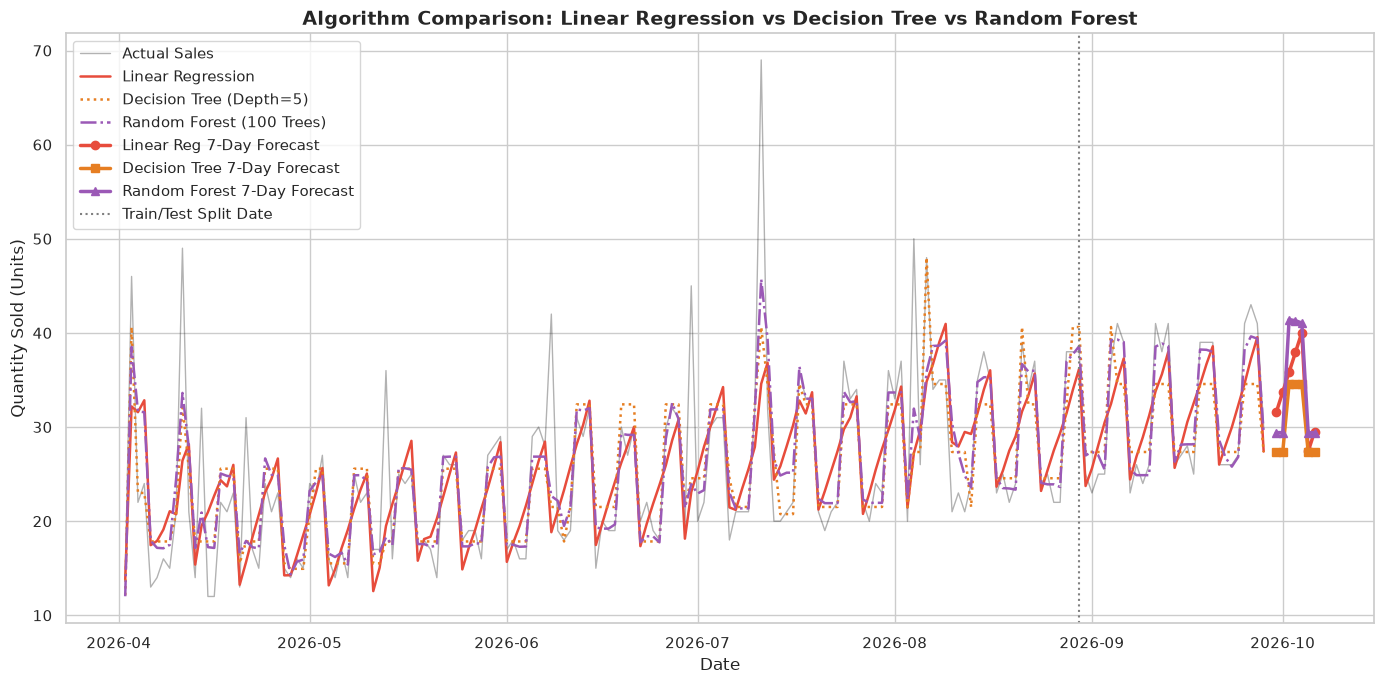

In [8]:
# 8. Visualizing Alternative Algorithms: Decision Tree & Random Forest vs. Linear Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Train Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_fitted = dt_model.predict(prod1_df[features])
dt_preds = dt_model.predict(X_future)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_fitted = rf_model.predict(prod1_df[features])
rf_preds = rf_model.predict(X_future)

# Evaluate Metrics
dt_r2 = r2_score(y_test, dt_model.predict(X_test))
rf_r2 = r2_score(y_test, rf_model.predict(X_test))

print(f"Model Performance Comparison (R² Score on Test Set):")
print(f" - Linear Regression : {r2:.4f}")
print(f" - Decision Tree     : {dt_r2:.4f}")
print(f" - Random Forest    : {rf_r2:.4f}")

# Visual Comparison Plot
plt.figure(figsize=(14, 7))

# Actual Sales
plt.plot(prod1_df['sale_date'], prod1_df['quantity_sold'], label='Actual Sales', color='black', alpha=0.3, linewidth=1)

# Fits
plt.plot(prod1_df['sale_date'], prod1_fitted, label='Linear Regression', color='#e74c3c', linewidth=1.8)
plt.plot(prod1_df['sale_date'], dt_fitted, label='Decision Tree (Depth=5)', color='#e67e22', linestyle=':', linewidth=1.8)
plt.plot(prod1_df['sale_date'], rf_fitted, label='Random Forest (100 Trees)', color='#9b59b6', linestyle='-.', linewidth=1.8)

# 7-Day Forecasts
plt.plot(future_dates, future_preds, label='Linear Reg 7-Day Forecast', color='#e74c3c', marker='o', linewidth=2.5)
plt.plot(future_dates, dt_preds, label='Decision Tree 7-Day Forecast', color='#e67e22', marker='s', linewidth=2.5)
plt.plot(future_dates, rf_preds, label='Random Forest 7-Day Forecast', color='#9b59b6', marker='^', linewidth=2.5)

plt.title('Algorithm Comparison: Linear Regression vs Decision Tree vs Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity Sold (Units)', fontsize=12)
plt.axvline(x=prod1_test['sale_date'].min(), color='gray', linestyle=':', label='Train/Test Split Date')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 9. Model Accuracy Metrics Summary
Comparing $R^2$ Score, MAE, and RMSE metrics across Linear Regression, Decision Tree, and Random Forest models.

In [ ]:
# 9. Model Performance Accuracy Comparison Table
from IPython.display import display, Markdown

metrics_data = [
    {"Model": "Linear Regression", "R² Score": f"{r2:.4f}", "MAE (Units)": f"{mae:.2f}", "RMSE": f"{rmse:.2f}"},
    {"Model": "Decision Tree (depth=5)", "R² Score": f"{dt_r2:.4f}", "MAE (Units)": f"{mean_absolute_error(y_test, dt_model.predict(X_test)):.2f}", "RMSE": f"{np.sqrt(mean_squared_error(y_test, dt_model.predict(X_test))):.2f}"},
    {"Model": "Random Forest (100 trees)", "R² Score": f"{rf_r2:.4f}", "MAE (Units)": f"{mean_absolute_error(y_test, rf_model.predict(X_test)):.2f}", "RMSE": f"{np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))):.2f}"}
]

md_table = """### Model Accuracy Metrics Comparison
| Model | R² Score | MAE (Mean Absolute Error) | RMSE (Root Mean Squared Error) |
| :--- | :---: | :---: | :---: |
"""
for row in metrics_data:
    md_table += f"| **{row['Model']}** | `{row['R² Score']}` | `{row['MAE (Units)']} units` | `{row['RMSE']} units` |\n"

display(Markdown(md_table))

### Model Accuracy Metrics Comparison
| Model | R² Score | MAE (Mean Absolute Error) | RMSE (Root Mean Squared Error) |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | `0.7619` | `4.80 units` | `8.89 units` |
| **Decision Tree (depth=5)** | `0.4897` | `5.85 units` | `13.02 units` |
| **Random Forest (100 trees)** | `0.7591` | `4.23 units` | `8.94 units` |
